In [1]:
!pip install git+https://github.com/xinntao/Real-ESRGAN.git
!pip install git+https://github.com/sberbank-ai/Real-ESRGAN.git
!pip install huggingface-hub==0.25.2
!pip install basicsr
!pip install super-image
!pip install torch
!pip install torchvision
!pip install scikit-image

  Cloning https://github.com/xinntao/Real-ESRGAN.git to /tmp/pip-req-build-f97p06h4
  Running command git clone --filter=blob:none --quiet https://github.com/xinntao/Real-ESRGAN.git /tmp/pip-req-build-f97p06h4
  Resolved https://github.com/xinntao/Real-ESRGAN.git to commit a4abfb2979a7bbff3f69f58f58ae324608821e27
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.6/59.6 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.6 MB/s eta 0:00:00
   ━━

In [2]:
import requests
from PIL import Image
from io import BytesIO
from RealESRGAN import RealESRGAN
import torch
import torch.nn as nn
import torchvision.transforms as T
import numpy as np

/usr/local/lib/python3.12/dist-packages/RealESRGAN/model.py:59: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast()


In [3]:
import glob
from google.colab import drive
drive.mount('/gdrive', force_remount=True)

Mounted at /gdrive


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [5]:
device

'cuda'

In [ ]:
#DATA_PATH = "/gdrive/MyDrive/Super_Resolution/Data/Test_images_2023"
#DATA_PATH = "/gdrive/MyDrive/SR_seeds/Test_images_2023"
DATA_PATH = "/gdrive/MyDrive/SR_seeds/Grains_(Pasynkov)"

In [ ]:
all_orig_imgs = []
all_lr_imgs = []
for i in range(891, 892):
  img = Image.open(DATA_PATH + f"/grain_{i}.png").convert("RGB")

  all_orig_imgs.append(img)

  w, h = img.size

  lr_img = img.resize((int(w*1), int(h*1)))
  all_lr_imgs.append(lr_img)

In [6]:
transform = T.ToTensor()
to_pil = T.ToPILImage()

In [7]:
all_sr_imgs = []

# ESRGAN

In [8]:
model = RealESRGAN(device, scale=4)
model.load_weights('https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.5/RealESRGAN_x4.pth')

SAVE_PATH = "/gdrive/MyDrive/SR_seeds/ESRGAN_(Pasynkov)/"
import os
os.makedirs(SAVE_PATH, exist_ok=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:131: FutureWarning: 'cached_download' (from 'huggingface_hub.file_download') is deprecated and will be removed from version '0.26'. Use `hf_hub_download` instead.
  warnings.warn(warning_message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:672: FutureWarning: 'cached_download' is the legacy way to download files from the HF hub, please consider upgrading to 'hf_hub_download'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:90: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public m

RealESRGAN_x4.pth:   0%|          | 0.00/67.0M [00:00<?, ?B/s]

Weights downloaded to: https://github.com/xinntao/Real-ESRGAN/releases/download/v0.2.5/RealESRGAN_x4.pth


In [ ]:
i = 890

for img in all_lr_imgs:
    i += 1
    sr_img = model.predict(img)
    all_sr_imgs.append(sr_img)

    filename = f"{str(i).zfill(4)}.png"  # 0001.png, 0002.png ...
    sr_img.save(os.path.join(SAVE_PATH, filename))

# Evaluation

In [9]:
LR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/LR/"
HR_PATH = "/gdrive/MyDrive/SR_seeds/Evaluation/HR/"

In [10]:
all_lr_imgs = []
all_hr_imgs = []

In [12]:
for i in range(1,8):
    lr_img = Image.open(os.path.join(LR_PATH, f"lr_img_{i}.png")).convert("RGB")
    hr_img = Image.open(os.path.join(HR_PATH, f"hr_img_{i}.png")).convert("RGB")

    all_lr_imgs.append(lr_img)
    all_hr_imgs.append(hr_img)

In [13]:
import torch.nn.functional as F
from math import log10
from skimage.metrics import structural_similarity as ssim
import numpy as np

psnr_list = []
ssim_list = []

In [14]:
def compute_psnr(sr, hr):
    mse = F.mse_loss(sr, hr)
    if mse == 0:
        return 100
    return 10 * log10(1.0 / mse.item())


def compute_ssim(sr, hr):
    sr = sr.permute(1, 2, 0).cpu().numpy()
    hr = hr.permute(1, 2, 0).cpu().numpy()

    return ssim(sr, hr, channel_axis=2, data_range=1.0)

In [15]:
sr_results = []

In [16]:
def match_size(sr, hr):
    """
    HR to the size of SR through bilinear resize
    """
    sr_h, sr_w = sr.shape[-2], sr.shape[-1]
    hr = F.interpolate(hr.unsqueeze(0), size=(sr_h, sr_w), mode="bilinear", align_corners=False)
    return hr.squeeze(0)

In [17]:
for i, (lr_img, hr_img) in enumerate(zip(all_lr_imgs, all_hr_imgs)):

    # ===== SR inference =====
    lr_gray = lr_img.convert("RGB")

    w, h = lr_gray.size
    upscaled = lr_gray.resize((w*4, h*4))

    inp = transform(upscaled).unsqueeze(0).to(device)

    sr_img = model.predict(lr_gray)

    sr_tensor = transform(sr_img.convert("RGB"))

    sr_results.append(sr_img)

    # ===== HR tensor =====
    hr_tensor = transform(hr_img.convert("RGB"))

    # ===== ALIGN SIZE (КРИТИЧНО) =====
    if hr_tensor.shape != sr_tensor.shape:
        hr_tensor = match_size(sr_tensor, hr_tensor)

    # ===== METRICS =====
    psnr_val = compute_psnr(sr_tensor, hr_tensor)
    ssim_val = compute_ssim(sr_tensor, hr_tensor)

    psnr_list.append(psnr_val)
    ssim_list.append(ssim_val)

    print(f"[{i+1}] PSNR: {psnr_val:.3f} | SSIM: {ssim_val:.4f}")

[1] PSNR: 30.951 | SSIM: 0.8319
[2] PSNR: 26.660 | SSIM: 0.7362
[3] PSNR: 31.064 | SSIM: 0.8189
[4] PSNR: 28.878 | SSIM: 0.7529
[5] PSNR: 26.152 | SSIM: 0.6662
[6] PSNR: 26.926 | SSIM: 0.7293
[7] PSNR: 29.372 | SSIM: 0.7682


In [18]:
print("\n========== FINAL ==========")
print(f"Mean PSNR: {np.mean(psnr_list):.3f}")
print(f"Mean SSIM: {np.mean(ssim_list):.4f}")


========== FINAL ==========
Mean PSNR: 28.572
Mean SSIM: 0.7577


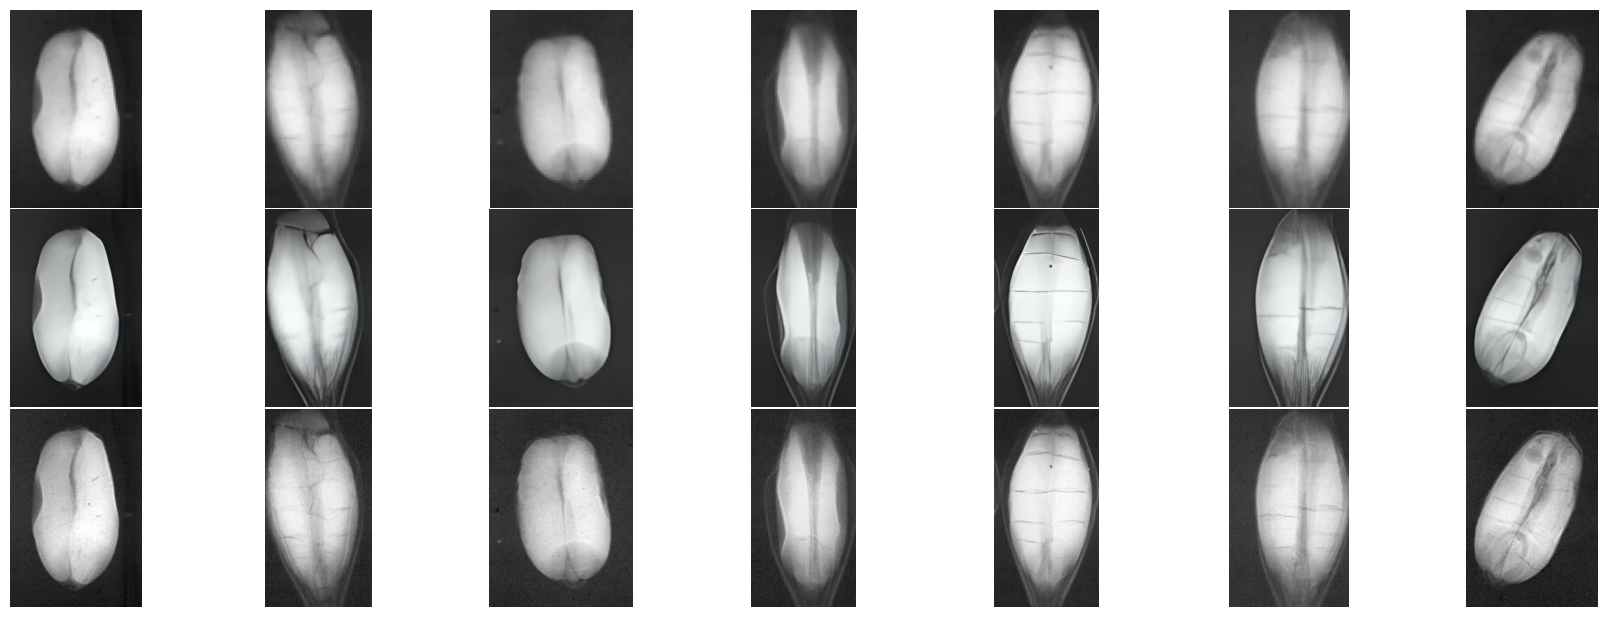

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 7, figsize=(18, 6))

plt.subplots_adjust(wspace=0.01, hspace=0.01)

for i in range(7):

    # ===== LR =====
    axes[0, i].imshow(all_lr_imgs[i])
    axes[0, i].axis("off")

    # ===== SR =====
    axes[1, i].imshow(sr_results[i].resize(all_hr_imgs[i].size), cmap="gray")
    axes[1, i].axis("off")

    # ===== HR =====
    axes[2, i].imshow(all_hr_imgs[i])
    axes[2, i].axis("off")

plt.tight_layout(pad=0.1)
plt.show()
